In [1]:
%pip install ipympl
%matplotlib widget

Note: you may need to restart the kernel to use updated packages.


In [2]:
from enum import auto
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft
from scipy.fft import fft, fftfreq, fftshift, ifft

In [3]:
def transform(file_name):
    sample_rate, data = wavfile.read(file_name)
    left_data = data[:, 0]
    right_data = data[:, 1]
    
    f_transform_left = fft(left_data)
    f_left = fftfreq(len(left_data), 1/sample_rate)
    amplitude_left = np.abs(f_transform_left) / (len(left_data) / 2)

    f_transform_right = fft(right_data)
    f_right = fftfreq(len(right_data), 1/sample_rate)
    amplitude_right = np.abs(f_transform_right) / (len(right_data) / 2)

    return left_data, f_transform_left, f_left, amplitude_left, right_data, f_transform_right, f_right, amplitude_right, sample_rate

In [4]:
def plot(x, y, title, xlabel, ylabel):
    plt.figure(figsize=(10, 4))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.plot(x, y)
    plt.tight_layout()
    plt.show()


C:\Users\eranm\AppData\Local\Temp\ipykernel_2552\730090391.py:2: WavFileWarning: Reached EOF prematurely; finished at 44015767 bytes, expected 4294967303 bytes from header.
  sample_rate, data = wavfile.read(file_name)


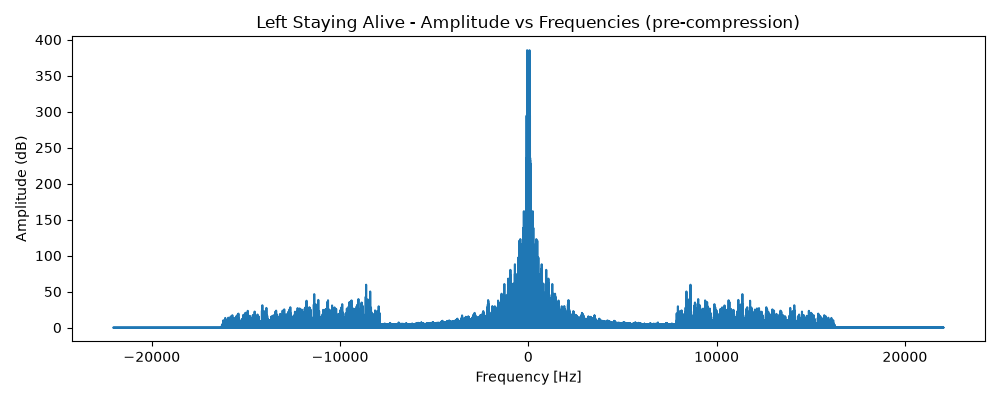

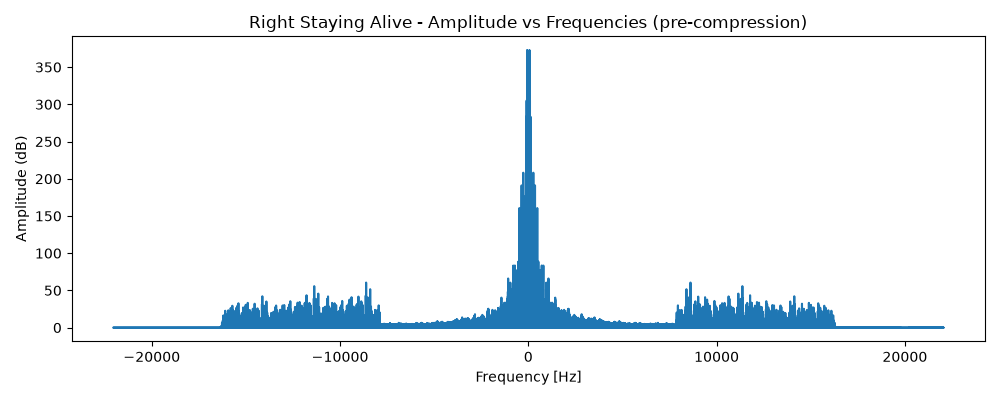

In [ ]:
right_limit = 23000

left_data, f_transform_left, f_left, amplitude_left, right_data, f_transform_right, f_right, amplitude_right, sample_rate = transform('ishst.wav')
plot(f_left, amplitude_left,  'Left I Saw Her Standing There - Amplitude vs Frequencies (pre-compression)', 'Frequency [Hz]', 'Amplitude (dB)')
plot(f_right,  amplitude_right,  'Right I Saw Her Standing There - Amplitude vs Frequencies (pre-compression)', 'Frequency [Hz]', 'Amplitude (dB)')

In [6]:
def remove_dc_offset(f_transform, data):
    f_transform[0] = 0
    amplitude = np.abs(f_transform) / (len(data) / 2)
    return amplitude, f_transform

In [7]:
def adjust_to_speaker_freqs(sample_rate, f_transform, n):
    #35Hz to #20kHz
    #find indices by sampling frequency/#samples * frequency
    min_freq_index = int(35*n/sample_rate)
    max_freq_index = int(20000*n/sample_rate)
    f_transform[:min_freq_index] = 0
    f_transform[-min_freq_index:] = 0
    
    f_transform[max_freq_index:-max_freq_index] = 0
    
    amplitude = np.abs(f_transform) / (n / 2)
    return amplitude, f_transform

In [8]:
def adjust_to_iphone_freqs(sample_rate, f_transform, n):
    #35Hz to #20kHz
    #find indices by sampling frequency/#samples * frequency
    min_freq_index = int(200*n/sample_rate)
    max_freq_index = int(16000*n/sample_rate)
    f_transform[:min_freq_index] = 0
    f_transform[-min_freq_index:] = 0
    
    f_transform[max_freq_index:-max_freq_index] = 0
    
    amplitude = np.abs(f_transform) / (n / 2)
    return amplitude, f_transform

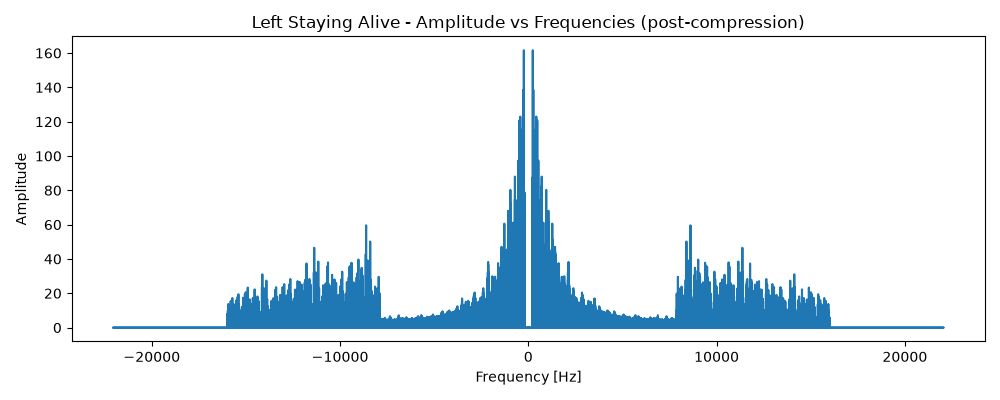

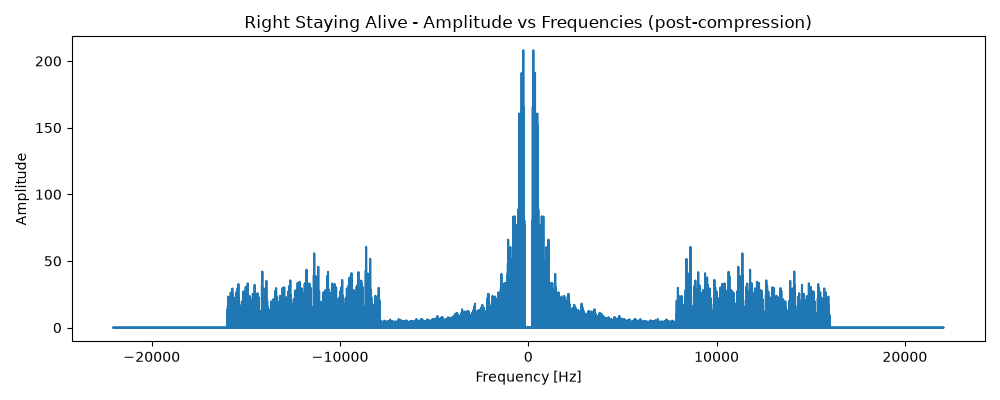

In [ ]:
amplitude_left_new, f_transform_left_new = adjust_to_iphone_freqs(sample_rate, f_transform_left, len(f_transform_left))
amplitude_right_new, f_transform_right_new = adjust_to_iphone_freqs(sample_rate, f_transform_right, len(f_transform_right))

# Plot post-compression in decibels (dB)
plot(f_left, amplitude_left_new,  'Left I Saw Her Standing There - Amplitude vs Frequencies (post-compression)', 'Frequency [Hz]', 'Amplitude')
plot(f_right, amplitude_right_new,  'Right I Saw Her Standing There - Amplitude vs Frequencies (post-compression)', 'Frequency [Hz]', 'Amplitude')

In [10]:
def inverse_transform(left, right, sample_rate, output_filename):
    reconstructed_left = ifft(left)
    reconstructed_right = ifft(right)

    reconstructed_left_real = np.real(reconstructed_left)
    reconstructed_right_real = np.real(reconstructed_right)
  
    reconstructed_real = np.stack((reconstructed_left_real, reconstructed_right_real), axis=1)
    audio_data_int16 = np.int16(np.clip(reconstructed_real, -32768, 32767))
    
    wavfile.write(output_filename, sample_rate, audio_data_int16)

    return audio_data_int16

4112.339600245513


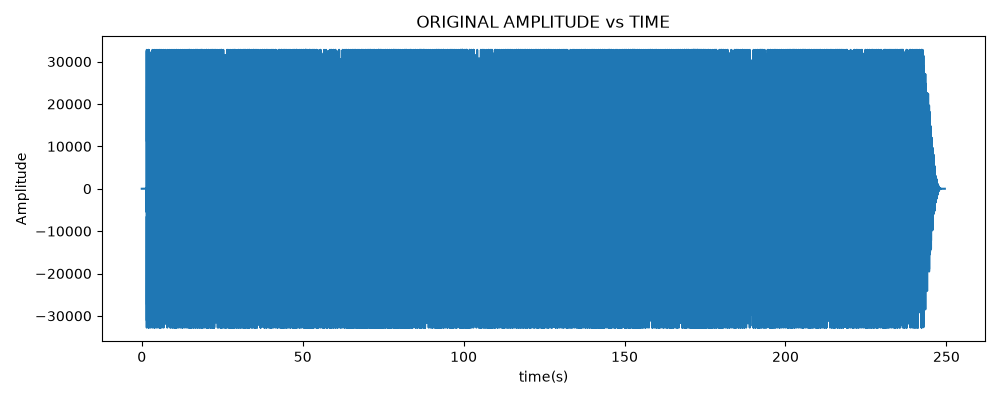

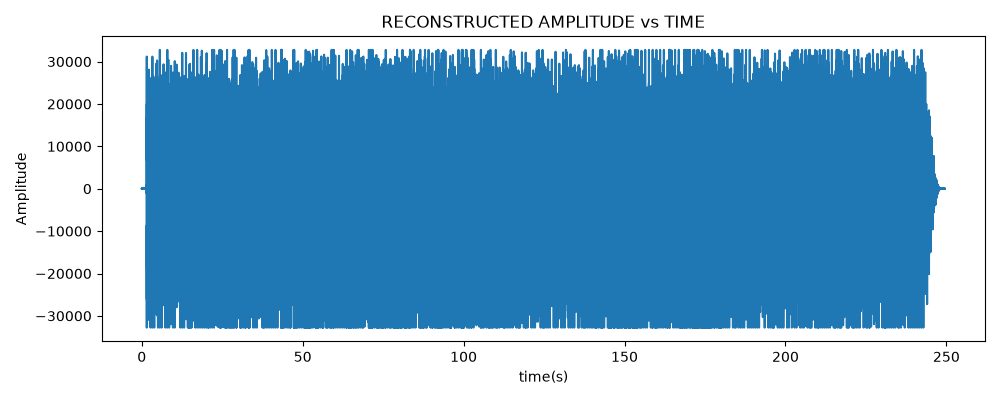

In [ ]:
reconstructed_data = inverse_transform(f_transform_left_new, f_transform_right_new, sample_rate, 'ishst_reconstructed.wav')
original_data = np.stack((left_data, right_data), axis=1)

delta = reconstructed_data - original_data
print(np.mean(np.abs(delta)))
reconstructed_ld = reconstructed_data[:, 0]
duration = len(original_data) / sample_rate
time = np.linspace(0.0, duration, num=len(original_data))

dbfs_ref = 32768.0
plot(time, left_data, 'ORIGINAL AMPLITUDE vs TIME', 'time(s)', 'Amplitude')
plot(time, reconstructed_ld, 'RECONSTRUCTED AMPLITUDE vs TIME', 'time(s)', 'Amplitude')